# High Temperature Treatment of the RxSM

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pandas as pd

import multiprocessing as mp
from joblib import Parallel, delayed

from tqdm.notebook import tqdm

import os

from cosmoTransitions import transitionFinder
from cosmoTransitions import pathDeformation as pthd

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

from time import perf_counter

import Higgs.predictions as HP
import Higgs.bounds as HB
import Higgs.signals as HS

pred = HP.Predictions()
bounds = HB.Bounds('/home/diegogt/hbdataset/')
signals = HS.Signals('/home/diegogt/hsdataset')

from RxSM_Model import RxSM

def physical_to_lagrangian(m1, m2, theta, v, lHS, lS, mu3):
    lH   = (m1**2 * np.cos(theta)**2 + m2**2 * np.sin(theta)**2)/(2 * v**2)
    muHS = np.sin(theta) * np.cos(theta) / v * (m1**2 - m2**2)
    muS2 = 0.5 * lHS * v**2 - (m1**2 * np.sin(theta)**2 + m2**2 * np.cos(theta)**2)
    muH2 = lH * v**2
    mu13 = - 0.5 * v**2 * muHS

    return dict(muH2=muH2, lH=lH, mu13=mu13, muHS=muHS, lHS=lHS, mu3=mu3, lS=lS, muS2=muS2)

## $Z_2$ Symmetric Model

In [2]:
th, mu3 = 0.0, 0.0
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

m1  = 125
m2  = 54.285714
th  = 0.0
v0  = 246.22
lHS = 0.184207
lS  = 0.081
mu3 = 0

# Lagrangian Parameters
p = physical_to_lagrangian(m1=m1, m2=m2, theta=th, v=v0, lHS=lHS, lS=lS, mu3=mu3)
lH, muH2, muS2 = p['lH'], p['muH2'], p['muS2']

# Thermal Coefficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
cS = lS/4 + lHS/6

# Transition Temperatures
T0h2 = muH2 / cH
T0s2 = muS2 / cS
Tc2 = (-np.sqrt(lS)*muH2 + np.sqrt(lH)*muS2) / (cS*np.sqrt(lH) - cH*np.sqrt(lS))

# VEVs
vTc2 = (muH2 - cH*Tc2) / lH
wTc2 = (muS2 - cS*Tc2) / lS

print(f'Tc = {np.sqrt(Tc2):.2f} GeV | xic= {np.sqrt(vTc2/Tc2):.4f}')

Tc = 114.76 GeV | xic= 1.2087


In [3]:
# Fixed Inputs
m1, v   = 125, 246.22
th, mu3 = 0.0, 0.0
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Create the grid
N = 100
lHS = np.geomspace(1e-3, 1, N)
lS  = np.geomspace(1e-6,  1,  N)
m2  = np.linspace(5,  m1/2,  N)
LHS, LS, M2 = np.meshgrid(lHS, lS, m2, indexing='ij')

# Lagrangian Parameters
p = physical_to_lagrangian(m1=m1, m2=M2, theta=th, v=v, lHS=LHS, lS=LS, mu3=mu3)
lH, muH2, muS2 = p['lH'], p['muH2'], p['muS2']

# Thermal Coefficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*LHS) / 48
cS = LS/4 + LHS/6

# Transition Temperatures
T0h2 = muH2 / cH
T0s2 = muS2 / cS
Tc2 = (-np.sqrt(LS)*muH2 + np.sqrt(lH)*muS2) / (cS*np.sqrt(lH) - cH*np.sqrt(LS))

# VEVs
vTc2 = (muH2 - cH*Tc2) / lH
wTc2 = (muS2 - cS*Tc2) / LS

# Validity Mask
valid = (
    (muS2 > 0) & (LS > 0) & (Tc2 > 0) 
    & (Tc2 < T0h2) & (Tc2 < T0s2) & (T0s2 > T0h2) 
    & (LHS > 2*np.sqrt(lH*LS)) & (LS > (LHS*v**2 - 2*M2**2)**2 / (2*v**2*m1**2))
)

# Save only relevant data
idx = np.where(valid)
resultsZ2 = dict(
    lHS=LHS[idx], lS=LS[idx], m2=M2[idx],
    Tc=np.sqrt(Tc2[idx]),
    vTc=np.sqrt(vTc2[idx]),
    wTc=np.sqrt(wTc2[idx]),
    xic=np.sqrt(vTc2[idx])/np.sqrt(Tc2[idx])
)

resultsZ2_df = pd.DataFrame(resultsZ2)

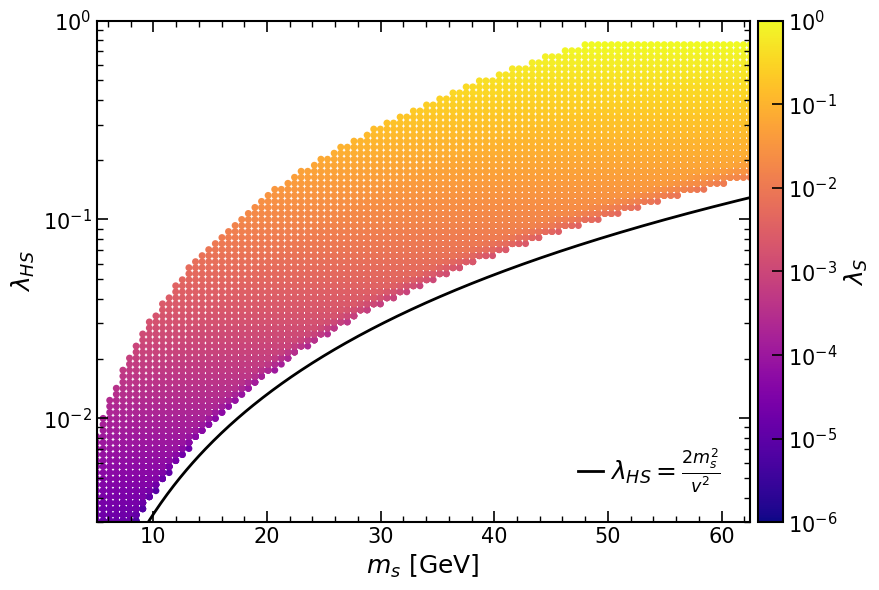

In [4]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_s^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_s \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_m2-lHS_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


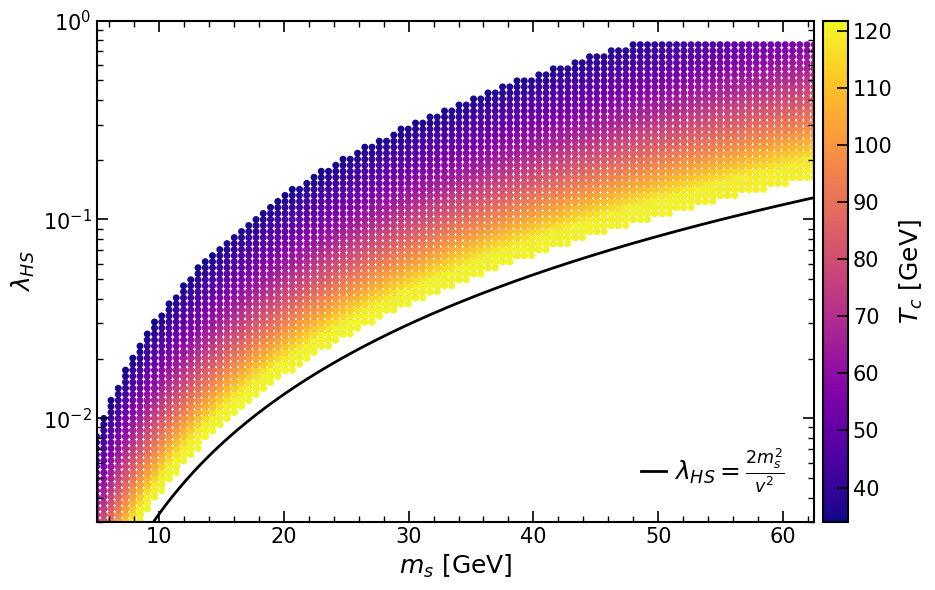

In [5]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = Normalize(vmin=df['Tc'].min(), vmax=df['Tc'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.71, 6))

ax.scatter(df['m2'], df['lHS'], c=df['Tc'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_s^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_s \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T_c \ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_m2-lHS_Tc_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


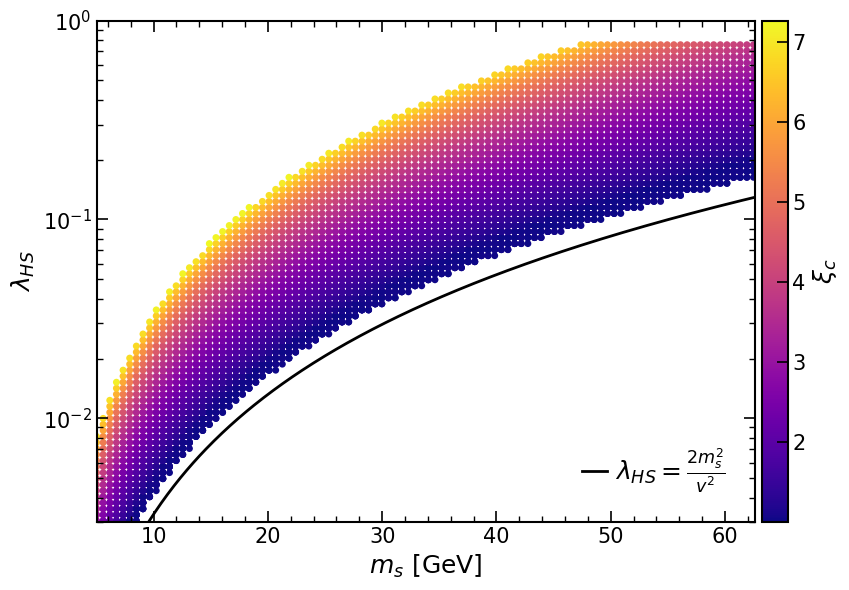

In [20]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = Normalize(vmin=df['xic'].min(), vmax=df['xic'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['xic'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_s^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_s \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\xi_c$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_m2-lHS_xic_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


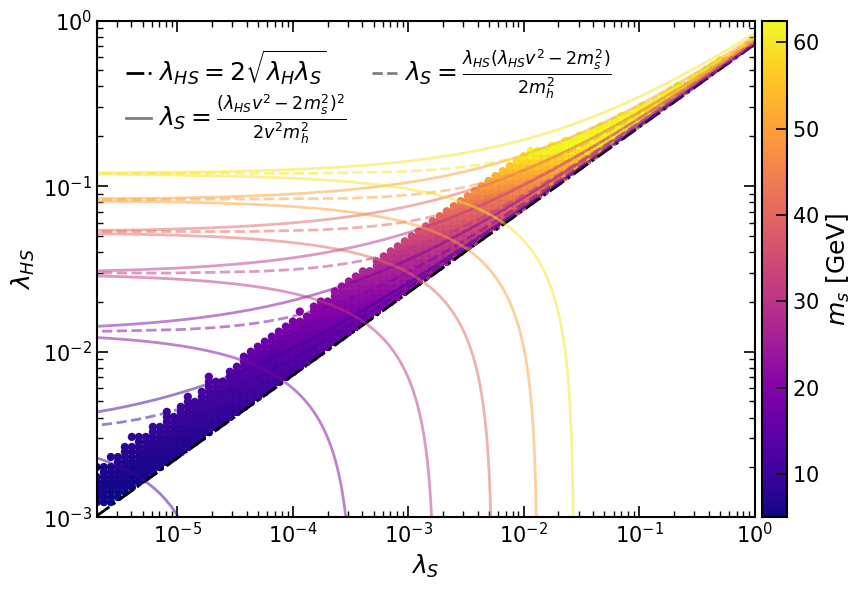

In [8]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_s\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_s^2)^2}{2v^2m_h^2}$"),
                mlines.Line2D([], [], color='k', linestyle='--', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{\lambda_{HS}(\lambda_{HS}v^2 - 2m_s^2)}{2m_h^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_lS-lHS_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


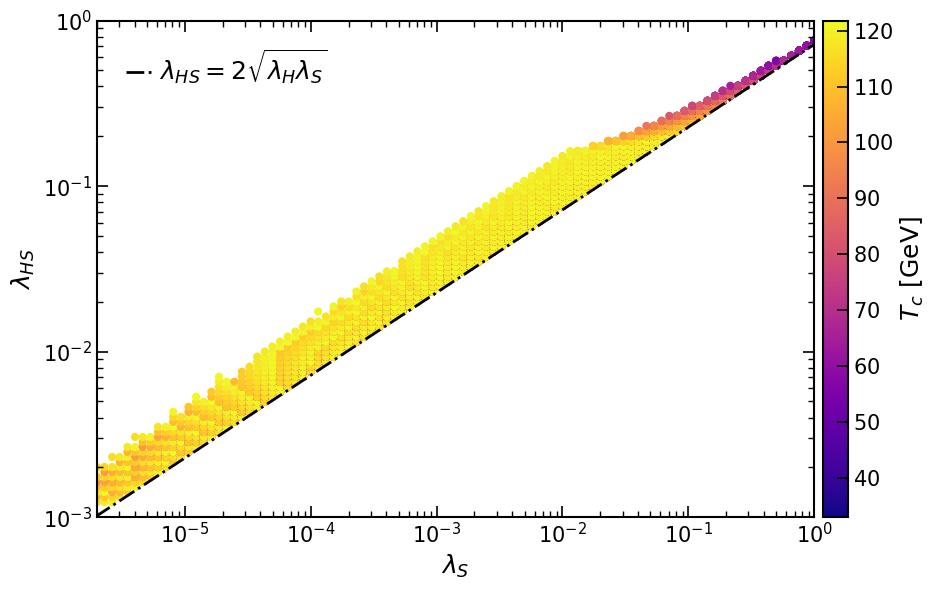

In [22]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['Tc'].min(), vmax=df['Tc'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.71, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

sc = ax.scatter(df['lS'], df['lHS'], c=df['Tc'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T_c\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_lS-lHS_Tc_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


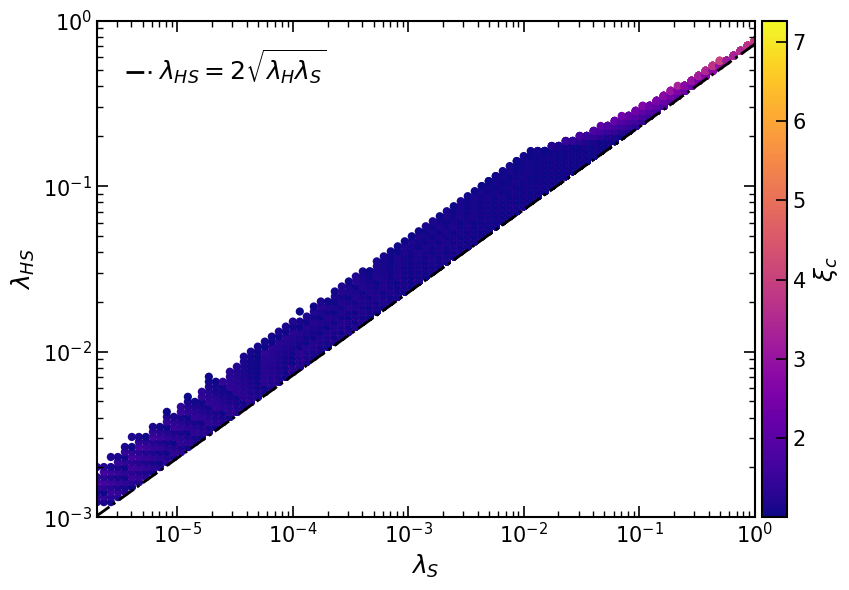

In [21]:
df = resultsZ2_df[(resultsZ2_df.xic>1)&(resultsZ2_df.Tc>30)&(resultsZ2_df.lS>(resultsZ2_df.lHS*(resultsZ2_df.lHS*v**2-2*resultsZ2_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['xic'].min(), vmax=df['xic'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

sc = ax.scatter(df['lS'], df['lHS'], c=df['xic'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\xi_c$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"Figures/HT_Scan/Z2_Scan_lS-lHS_xic_{N}.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Generic Model

### Funcions

In [6]:
def create_params(m2, th, lHS, lS, mu3):
    # Fixed Inputs
    m1, v   = 125.2, 246.22
    g  = 0.6528226789050443
    gp = 0.34994875330215097
    yb = 0.024025892825142788
    yt = 0.9902137038141565

    p = physical_to_lagrangian(m1, m2, th, v, lHS, lS, mu3)
    muH2, lH, mu13, muHS, muS2 = p['muH2'], p['lH'], p['mu13'], p['muHS'], p['muS2']

    cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
    cS = lS/4 + lHS/6
    c1 = (-mu3 + 2*muHS)/12

    return{
        "lH": lH, "lHS": lHS, "muHS": muHS, "lS": lS,
        "mu3": mu3, "muH2": muH2, "muS2": muS2, "mu13": mu13,
        "cH": cH, "cS": cS, "c1": c1
    }

def cubic_real_roots_vec(a, b, c, d, tol=1e-10):
    """
    Finds real roots of ax^3 + bx^2 + cx + d = 0 for vectorized NumPy arrays.
    Returns an array of shape (..., 3) padded with NaNs where fewer than 3 roots exist.
    """
    a, b, c, d = np.broadcast_arrays(a, b, c, d)
    a, b, c, d = a.astype(float), b.astype(float), c.astype(float), d.astype(float)
    
    # Depress the cubic: t^3 + pt + q = 0
    b_a, c_a, d_a = b / a, c / a, d / a
    shift = b_a / 3.0
    p = c_a - b_a**2 / 3.0
    q = 2.0 * b_a**3 / 27.0 - b_a * c_a / 3.0 + d_a
    disc = -4.0 * p**3 - 27.0 * q**2
    
    roots = np.full(a.shape + (3,), np.nan)
    three = disc > tol
    one = ~three  # Covers disc <= tol safely

    # --- 3 Real Roots (Viète's Method) ---
    if np.any(three):
        pp, qq = p[three], q[three]
        r = np.sqrt(-pp / 3.0)
        arg = np.clip((3.0 * qq) / (2.0 * pp * r), -1.0, 1.0)
        phi = np.arccos(arg)
        
        k = np.arange(3)
        angles = phi[..., None] / 3.0 - (2.0 * np.pi * k) / 3.0
        roots[three] = 2.0 * r[..., None] * np.cos(angles) - shift[three, ..., None]

    # --- 1 Real Root (Cardano's Method) ---
    if np.any(one):
        pp, qq = p[one], q[one]
        sq = np.sqrt(np.maximum(qq**2 / 4.0 + pp**3 / 27.0, 0.0))
        cbrt = lambda x: np.sign(x) * np.abs(x)**(1.0 / 3.0)
        roots[one, 0] = cbrt(-qq / 2.0 + sq) + cbrt(-qq / 2.0 - sq) - shift[one]

    return roots

def find_w_vec(T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None] if pointwise else T_list[None, :]                         
    # (N, 1)
    lS   = params["lS"][:, None]                  
    mu3  = params["mu3"][:, None]
    muS2 = params["muS2"][:, None]
    mu13 = params["mu13"][:, None]
    cS = params["cS"][:, None]                 
    c1   = params["c1"][:, None]

    # Compute the Roots
    dSy = c1*T**2 + mu13
    cSy = cS*T**2 - muS2
    bSy = np.broadcast_to(-mu3, dSy.shape)
    aSy = np.broadcast_to(lS, dSy.shape)
    roots_S = cubic_real_roots_vec(aSy, bSy, cSy, dSy)

    d2V_S = cSy[..., None] + 2*bSy[..., None]*roots_S + 3*aSy[..., None]*roots_S**2
    valid_S = (d2V_S > 0) & ~np.isnan(roots_S)
    w = np.where(valid_S, roots_S, np.nan)    
    return w

def find_EW_vec(T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None] if pointwise else T_list[None, :] 
    lH   = params["lH"][:, None]
    lHS  = params["lHS"][:, None]
    muHS = params["muHS"][:, None]
    muH2 = params["muH2"][:, None]
    muS2 = params["muS2"][:, None]
    mu3  = params["mu3"][:, None]
    mu13 = params["mu13"][:, None]
    cH   = params["cH"][:, None]
    cS_p = params["cS"][:, None]
    c1   = params["c1"][:, None]

    Tew = np.sqrt(muH2 / cH)                                 # (N, 1)
    above = T > Tew                                           # (N, M)

    with np.errstate(invalid="ignore"):
        disc = -2*cH*lHS*T**2 + 2*lHS*muH2 + muHS**2
        rootdisc = np.sqrt(np.where(disc >= 0, disc, np.nan))
    sp = (-muHS + rootdisc) / lHS
    sm = (-muHS - rootdisc) / lHS

    aE = np.broadcast_to(lHS_a := (params["lS"][:, None] - lHS**2/(4*lH)),
                          (lH.shape[0], T.shape[-1]))
    bE = np.broadcast_to(-params["mu3"][:, None] - (3*lHS*muHS)/(4*lH), aE.shape)
    cE = (cS_p - (cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2
    dE = mu13 + (muH2*muHS)/(2*lH) + (c1 - (cH*muHS)/(2*lH))*T**2

    roots_E = cubic_real_roots_vec(aE, bE, cE, dE)            # (N, M, 3)

    inrange = (roots_E > sm[..., None]) & (roots_E < sp[..., None]) & ~np.isnan(roots_E)

    d2V_E = cE[..., None] + 2*bE[..., None]*roots_E + 3*aE[..., None]*roots_E**2
    valid_E = inrange & (d2V_E > 0)

    vs = np.where(valid_E, roots_E, np.nan)                   # (N, M, 3)

    with np.errstate(invalid="ignore"):
        vh2 = (2*muH2[..., None] - 2*cH[..., None]*T[..., None]**2
               - 2*muHS[..., None]*vs - lHS[..., None]*vs**2) / (2*lH[..., None])
    vh = np.sqrt(np.where(vh2 >= 0, vh2, np.nan))

    vh = np.where(above[..., None], np.nan, vh)
    vs = np.where(above[..., None], np.nan, vs)

    return vh, vs

def VHT_vec(h, s, T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None, None] if pointwise else T_list[None, :, None] 
    cH   = params["cH"][:, None, None]
    muH2 = params["muH2"][:, None, None]
    lH   = params["lH"][:, None, None]
    c1   = params["c1"][:, None, None]
    mu13 = params["mu13"][:, None, None]
    cS   = params["cS"][:, None, None]
    muS2 = params["muS2"][:, None, None]
    mu3  = params["mu3"][:, None, None]
    lS   = params["lS"][:, None, None]
    muHS = params["muHS"][:, None, None]
    lHS  = params["lHS"][:, None, None]

    V = ((cH*T**2 - muH2)*(h**2)/2 + lH*(h**4)/4
         + (c1*T**2 + mu13)*s + (cS*T**2 - muS2)*(s**2)/2
         - mu3*(s**3)/3 + lS*(s**4)/4
         + 0.5*muHS*s*h**2 + 0.25*lHS*s**2*h**2)
    return V

def global_symmetric_min_vec(T_list, params, pointwise=False):
    w = find_w_vec(T_list, params, pointwise=pointwise)  
    Vs = VHT_vec(np.zeros_like(w), w, T_list, params, pointwise=pointwise)                            # (N, M, 3)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)                           # (N, M)
    w_sel = np.take_along_axis(w, idx[..., None], axis=-1)[..., 0]
    V_sel = np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0]
    w_sel = np.where(all_nan, np.nan, w_sel)
    V_sel = np.where(all_nan, np.nan, V_sel)
    return w_sel, V_sel  

def global_EW_min_vec(T_list, params, pointwise=False):
    vh, vs = find_EW_vec(T_list, params, pointwise=pointwise)
    Vs = VHT_vec(vh, vs, T_list, params, pointwise=pointwise)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)
    vh_sel = np.where(all_nan, np.nan, np.take_along_axis(vh, idx[..., None], axis=-1)[..., 0])
    vs_sel = np.where(all_nan, np.nan, np.take_along_axis(vs, idx[..., None], axis=-1)[..., 0])
    V_sel  = np.where(all_nan, np.nan, np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0])
    return vh_sel, vs_sel, V_sel

def delta_V_vec(T_list, params, pointwise=False):
    _, V_sym = global_symmetric_min_vec(T_list, params, pointwise=pointwise)
    _, _, V_ew = global_EW_min_vec(T_list, params, pointwise=pointwise)
    return V_ew - V_sym

def find_Tc_vec(params, Tmin=1e-3, Tmax=300, nscan=150, n_bisect=52):
    N = params["lH"].shape[0]
    T_list = np.linspace(Tmin, Tmax, nscan)              # (M,) — shared scan grid, M = nscan

    dV = delta_V_vec(T_list, params, pointwise=False)                      # (N, M): params 1D (N,), T 1D (M,) -> (N,M)

    s = np.sign(dV)
    finite_pair = np.isfinite(dV[:, :-1]) & np.isfinite(dV[:, 1:])
    change = (np.diff(s, axis=1) != 0) & finite_pair       # (N, M-1): True where consecutive columns flip sign

    Tew = np.sqrt(params["muH2"] / params["cH"])            # (N,)
    below_Tew = T_list[None, :-1] < Tew[:, None]             # (N, M-1): broadcast the 1D grid against each row's own Tew
    change = change & below_Tew

    has_root = change.any(axis=1)                            # (N,) — does row i have any valid crossing at all
    idx = np.argmax(change, axis=1)                           # (N,) — column index of first True per row

    lo = T_list[idx]                                            # (N,) — index the *shared* 1D grid with per-row indices
    hi = T_list[idx + 1]                                         # (N,)

    def dV_at(Tvec):
        return delta_V_vec(Tvec, params, pointwise=True)[:, 0]                                   

    sign_lo = np.sign(dV_at(lo))
    for _ in range(n_bisect):
        mid = 0.5 * (lo + hi)
        sign_mid = np.sign(dV_at(mid))
        go_right = sign_mid == sign_lo
        lo = np.where(go_right, mid, lo)
        hi = np.where(go_right, hi, mid)
        sign_lo = np.where(go_right, sign_mid, sign_lo)

    Tc = np.where(has_root, 0.5 * (lo + hi), np.nan)
    return Tc



In [7]:
def build_grid(m2_region, th_region, lHS_region, lS_region, mu3_region):
    m2_min, m2_max, m2_n    = m2_region
    th_min, th_max, th_n    = th_region
    lHS_min, lHS_max, lHS_n = lHS_region
    lS_min, lS_max, lS_n    = lS_region
    mu3_min, mu3_max, mu3_n = mu3_region

    M2  = np.linspace(m2_min, m2_max, m2_n)
    TH  = np.insert(np.geomspace(th_min, th_max, th_n), 0, 0.0)
    LHS = np.geomspace(lHS_min, lHS_max, lHS_n)
    LS  = np.geomspace(lS_min, lS_max, lS_n)
    MU3 = np.insert(np.geomspace(mu3_min, mu3_max, mu3_n), 0, 0.0)

    m2, th, lHS, lS, mu3 = np.meshgrid(M2, TH, LHS, LS, MU3, indexing='ij')
    return m2.ravel(), th.ravel(), lHS.ravel(), lS.ravel(), mu3.ravel()


def scan_chunk_Z2(chunk):
    """Vectorized worker: takes an (n_chunk, 5) array of (m2, th, lHS, lS, mu3)
    and returns a DataFrame of results for the whole chunk in one shot."""
    chunk = np.asarray(chunk)
    m2, th, lHS, lS, mu3 = chunk[:, 0], chunk[:, 1], chunk[:, 2], chunk[:, 3], chunk[:, 4]

    params = create_params(m2, th, lHS, lS, mu3)
    Tc = find_Tc_vec(params)
    vh, _, _ = global_EW_min_vec(Tc, params, pointwise=True)
    vh = vh[:, 0]
    xic = vh / Tc

    return pd.DataFrame({'m2': m2, 'th': th, 'lHS': lHS, 'lS': lS, 'mu3': mu3,
                          'Tc': Tc, 'xic': xic})


def run_scan(points, output_csv='Z2_scan.csv', n_workers=-1,
             chunk_size=1331, checkpoint_every=10):
    """
    points: array-like of shape (N_total, 5), columns = (m2, th, lHS, lS, mu3)
    chunk_size: points per vectorized worker call (see benchmark: ~1000-1700
                is the sweet spot — big enough to amortize overhead, small
                enough that no single worker hogs a huge slice of the scan)
    checkpoint_every: flush to disk every this many *chunks*
    """
    points = np.asarray(points, dtype=float)

    if os.path.exists(output_csv):
        existing = pd.read_csv(output_csv)
        done = set(zip(existing['m2'].round(8), existing['th'].round(8),
                        existing['lHS'].round(8), existing['lS'].round(8),
                        existing['mu3'].round(8)))
        before = len(points)
        mask = np.array([tuple(np.round(p, 8)) not in done for p in points])
        points = points[mask]
        print(f"Resuming: {before - len(points)} points already done, {len(points)} remaining.")

    if len(points) == 0:
        return pd.read_csv(output_csv)

    write_header = not os.path.exists(output_csv)

    chunks = [points[i:i + chunk_size] for i in range(0, len(points), chunk_size)]

    parallel = Parallel(n_jobs=n_workers, return_as="generator")
    results_gen = parallel(delayed(scan_chunk_Z2)(c) for c in chunks)

    buffer = []
    for res_df in tqdm(results_gen, total=len(chunks)):
        buffer.append(res_df)
        if len(buffer) >= checkpoint_every:
            pd.concat(buffer, ignore_index=True).to_csv(
                output_csv, mode='a', header=write_header, index=False)
            write_header = False
            buffer = []

    if buffer:
        pd.concat(buffer, ignore_index=True).to_csv(
            output_csv, mode='a', header=write_header, index=False)

    return pd.read_csv(output_csv)

### $Z_2$ Results Again

#### Create the Data

In [29]:
m1, v = 125.2, 246.22
n = 200

m2_region  = (5.0, m1/2, n)
th_region  = (1e-5, 1e-2, 0)
lHS_region = (1e-3, 1, n)
lS_region  = (1e-6, 1, n)
mu3_region = (1e-4*v, v, 0)

m2, th, lHS, lS, mu3 = build_grid(m2_region, th_region, lHS_region, lS_region, mu3_region)

points = np.column_stack([m2, th, lHS, lS, mu3])

Results_df = run_scan(points, output_csv='HT_Z2_scan.csv', chunk_size=20**3)


Resuming: 8000000 points already done, 0 remaining.


#### Read the Data

In [ ]:
data = pd.read_csv('HT_Z2_scan.csv')
Results_df = pd.DataFrame(data).dropna(subset=["Tc"])

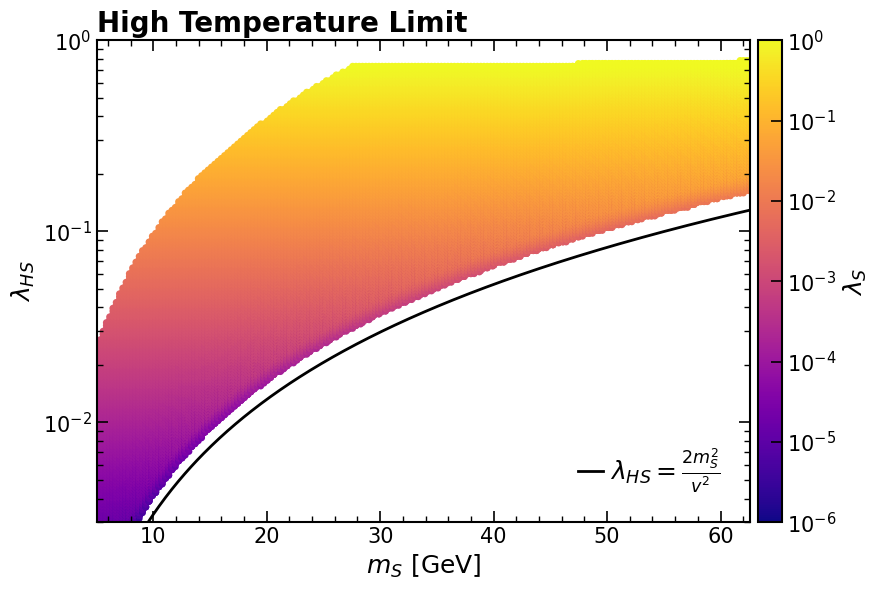

In [ ]:
df = Results_df[(Results_df.xic>1)&(Results_df.lS>(Results_df.lHS*(Results_df.lHS*v**2-2*Results_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/High_T/Z2_Scan_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()

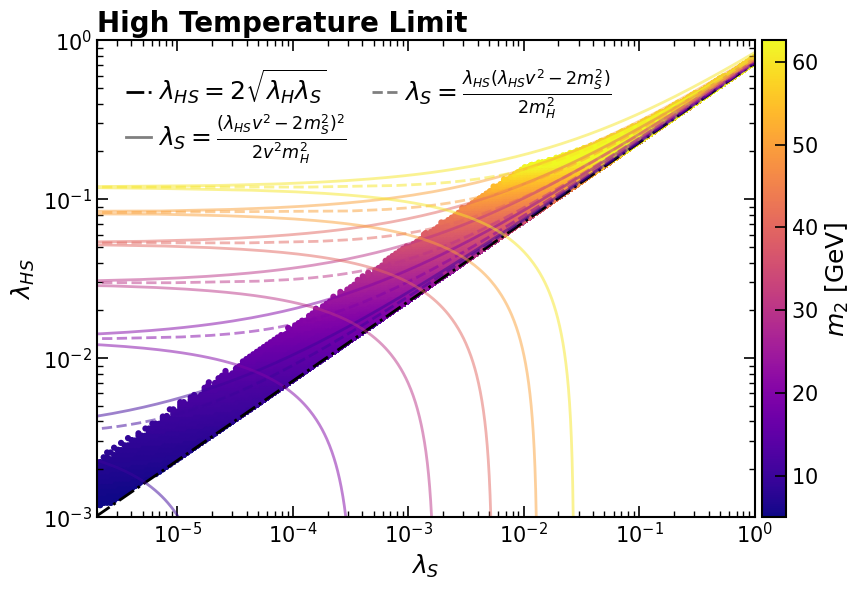

In [ ]:
df = Results_df[(Results_df.xic>1)&(Results_df.lS>(Results_df.lHS*(Results_df.lHS*v**2-2*Results_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=20, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$"),
                mlines.Line2D([], [], color='k', linestyle='--', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{\lambda_{HS}(\lambda_{HS}v^2 - 2m_S^2)}{2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/High_T/Z2_Scan_lS-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


### Generic Model

#### Create the Data

In [11]:
m1, v = 125.2, 246.22
n = 50

m2_region  = (5.0, m1/2, n)
th_region  = (1e-5, 1e-2, 3)
lHS_region = (1e-3, 1, n)
lS_region  = (1e-6, 1, n)
mu3_region = (1e-4*v, 1*v, 15)

m2, th, lHS, lS, mu3 = build_grid(m2_region, th_region, lHS_region, lS_region, mu3_region)

points = np.column_stack([m2, th, lHS, lS, mu3])

Results_df = run_scan(points, output_csv='HT_scan.csv', chunk_size=20**3)


  0%|          | 0/1000 [00:00<?, ?it/s]

#### Read the Data

In [4]:
data = pd.read_csv('HT_scan.csv')
Results_df = pd.DataFrame(data).dropna(subset=["Tc"])

In [8]:
DF = Results_df[Results_df.xic > 1].copy()
M2 = DF['m2'].values
TH = DF['th'].values
LHS = DF['lHS'].values
LS = DF['lS'].values
MU3 = DF['mu3'].values

params = create_params(M2, TH, LHS, LS, MU3)
w, Vw = global_symmetric_min_vec(np.array([0]), params)
vh, vs, Vew = global_EW_min_vec(np.array([0]), params)

DF['DeltaV0'] = Vw-Vew 

In [9]:
DF[(DF.lHS<1e-2)&(DF.th==0)&(DF.m2>50)&(DF.DeltaV0>0)]

,m2,th,lHS,lS,mu3,Tc,xic,DeltaV0
6248441,50.844898,0.0,0.004095,0.002024,4.753764,113.208041,1.286262,9.335180e+07
6249241,50.844898,0.0,0.004715,0.002024,4.753764,90.253664,2.089594,6.975933e+07
6250041,50.844898,0.0,0.005429,0.002024,4.753764,66.542645,3.258077,4.218193e+07
6250841,50.844898,0.0,0.006251,0.002024,4.753764,30.869200,7.780988,9.893735e+06
6412441,52.020408,0.0,0.008286,0.002024,4.753764,120.668956,1.042231,8.568735e+07
6413241,52.020408,0.0,0.009541,0.002024,4.753764,65.602638,3.317968,3.738029e+07
6568360,53.195918,0.0,0.004095,0.000494,2.462200,24.366899,9.951328,4.777554e+06
6732360,54.371429,0.0,0.008286,0.000494,2.462200,18.065816,13.515692,1.377104e+06
7053306,56.722449,0.0,0.009541,0.006251,9.178081,104.236071,1.581788,8.617822e+07
7206025,57.897959,0.0,0.002683,0.001526,4.753764,97.248486,1.826179,7.739412e+07


#### Plot the Data

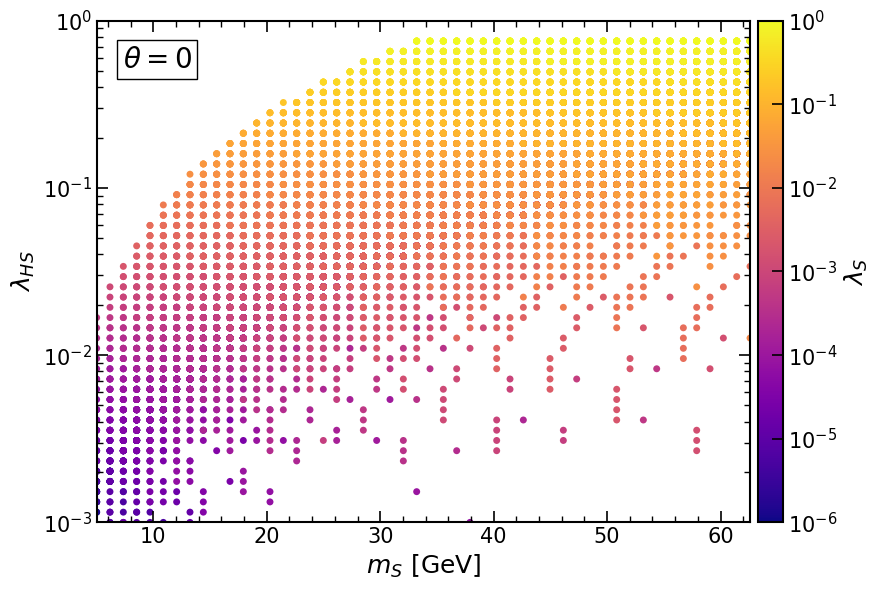

In [13]:
m1, v = 125.2, 246.22
df = DF[(DF.th==0)&(DF.xic>1)&(DF.DeltaV0>0)]

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

annotation = (rf"$\theta=0$")
ax.text(0.04, 0.95, annotation,transform=ax.transAxes,fontsize=20,verticalalignment='top',horizontalalignment='left',
       bbox=dict(facecolor='white', edgecolor='black', alpha=1))

#plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/HT_Scan/Scan_m2-lHS-Ls.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
Results_df[(Results_df.m2>60)&(Results_df.lHS<1e-1)&(Results_df.th==0)&(Results_df.xic>1)&(Results_df.lS>(Results_df.lHS*(Results_df.lHS*v**2-2*Results_df.m2**2))/(2*m1**2))]


,m2,th,lHS,lS,mu3,Tc,xic
7534825,60.24898,0.0,0.012649,0.001526,4.753764,62.086577,3.556483
7537652,60.24898,0.0,0.022230,0.000002,0.177201,102.219911,1.649323
7537879,60.24898,0.0,0.022230,0.000121,1.275290,100.756623,1.700004
7538906,60.24898,0.0,0.025595,0.006251,9.178081,77.777329,2.634172
7541014,60.24898,0.0,0.039069,0.000039,0.660533,73.314845,2.862108
...,...,...,...,...,...,...,...
7865781,62.60000,0.0,0.091030,0.000022,0.342122,23.652348,10.259795
7865927,62.60000,0.0,0.091030,0.000281,1.275290,87.590457,2.190444
7866073,62.60000,0.0,0.091030,0.003556,4.753764,25.843695,9.362964
7866138,62.60000,0.0,0.091030,0.010985,9.178081,38.655562,6.121090


## Plot the Potential

In [20]:
def create_params(m2, th, lHS, lS, mu3):
    # Fixed Inputs
    m1, v   = 125.2, 246.22
    g  = 0.6528226789050443
    gp = 0.34994875330215097
    yb = 0.024025892825142788
    yt = 0.9902137038141565

    p = physical_to_lagrangian(m1, m2, th, v, lHS, lS, mu3)
    muH2, lH, mu13, muHS, muS2 = p['muH2'], p['lH'], p['mu13'], p['muHS'], p['muS2']

    cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
    cS = lS/4 + lHS/6
    c1 = (-mu3 + 2*muHS)/12

    return{
        "lH": lH, "lHS": lHS, "muHS": muHS, "lS": lS,
        "mu3": mu3, "muH2": muH2, "muS2": muS2, "mu13": mu13,
        "cH": cH, "cS": cS, "c1": c1
    }

def VHT(X, T, params):
    h,s  = X
    muH2 = params['muH2']
    muS2 = params['muS2']
    lH   = params['lH']
    lS   = params['lS']
    lHS  = params['lHS']
    mu13  = params['mu13']
    mu3  = params['mu3']
    muHS = params['muHS']
    cH   = params['cH']
    cS   = params['cS']
    c1   = params['c1']

    Vth = (0.5 * (T**2 * cH - muH2) * h**2 + 0.25 * lH * h**4 
           + (c1 * T**2 + mu13) * s +  0.5 * (T**2 * cS - muS2) * s**2  - mu3/3 * s**3 + 0.25 * lS * s**4
           + 0.5 * muHS * h**2 * s + 0.25 * lHS * h**2 * s**2
           )

    return Vth

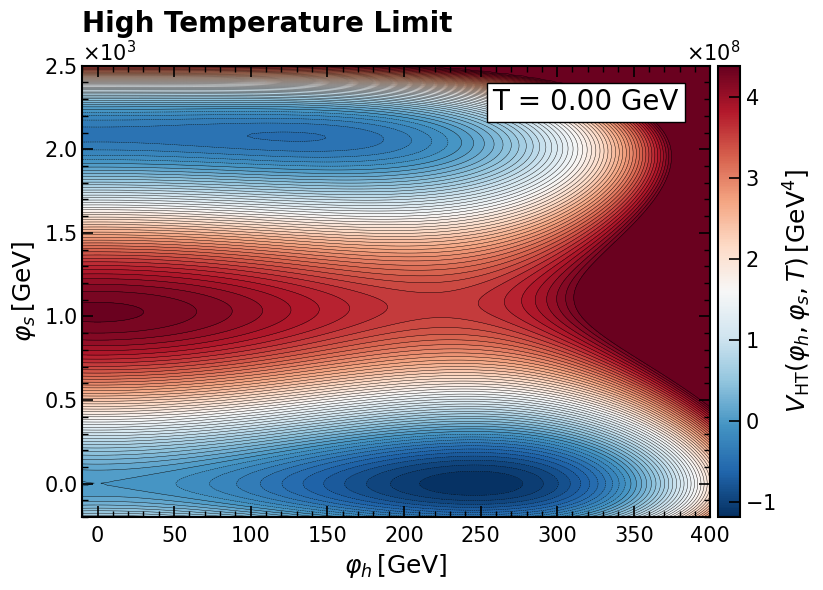

In [110]:
params = create_params(57.897959, 0.0, 0.002683, 0.001526, 4.753764)
T = 0

h_vals = np.linspace(-10, 400, 200)
s_vals = np.linspace(-200, 2500, 200)

H, S   = np.meshgrid(h_vals, s_vals)
V_grid = VHT((H, S), T, params)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 90))
V_shifted = V_plot - VHT((0.0, 0.0), T, params)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
                length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
                length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{HT}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2, 3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
                length=8, width=1.2, labelsize=15)

annotation = rf'T = {T:.2f} GeV'
ax.text(0.95, 0.95, annotation, transform=ax.transAxes, fontsize=20,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', alpha=1))

plt.title(rf"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

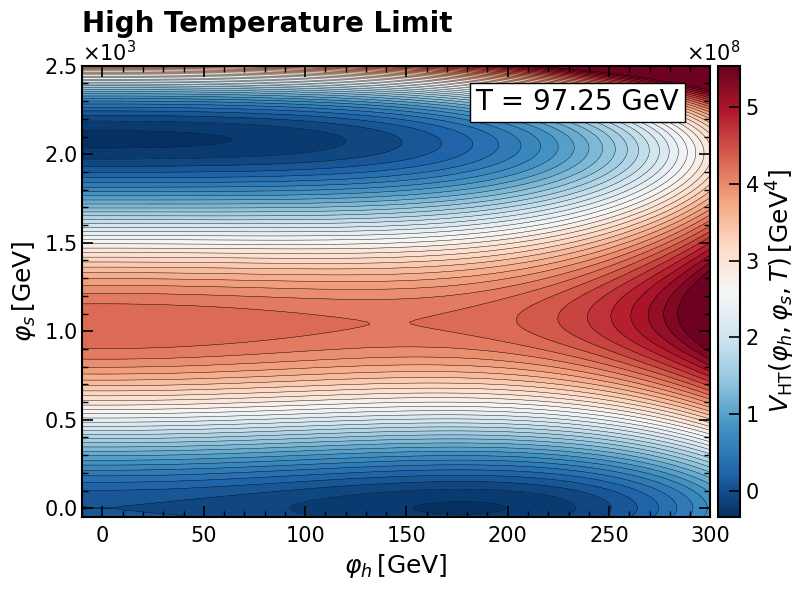

In [106]:
params = create_params(57.897959, 0.0, 0.002683, 0.001526, 4.753764)
T = 97.248486

h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-50, 2500, 200)

H, S   = np.meshgrid(h_vals, s_vals)
V_grid = VHT((H, S), T, params)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - VHT((0.0, 0.0), T, params)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
                length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
                length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{HT}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2, 3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
                length=8, width=1.2, labelsize=15)

annotation = rf'T = {T:.2f} GeV'
ax.text(0.95, 0.95, annotation, transform=ax.transAxes, fontsize=20,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', alpha=1))

plt.title(rf"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()